# Machine Unlearning Technique Comparison

Comparative analysis of **Exact Retraining**, **Gradient Ascent**, and **First-Epoch Reversal** unlearning methods.

This notebook compares three unlearning approaches:
- **Exact Retraining** (Gold Standard): Retrain on retain set only
- **Gradient Ascent** (Approximation): Fast approximation via gradient ascent on delete set
- **First-Epoch Reversal** (Checkpoint-based): Rewind to early checkpoint and retrain

Metrics compared: Forgetting (privacy), Utility (retained accuracy), and Efficiency (time)

In [136]:
import json
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Results from Both Techniques

In [137]:
# Configuration - Experiment Parameters
SEED = 123
DELETE_RATIO = 0.10

# Format variables for file paths
seed_str = f"{SEED:04d}"
delete_ratio_formatted = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")

# Load the two result files with proper naming convention
# gradient_ascent_file = f"../results/metadata/gradient_ascent_and_gold_seed_{seed_str}_{delete_ratio_formatted}_results.json"
gradient_ascent_file = f"../results/metadata/unlearning_seed_{seed_str}_{DELETE_RATIO}_results.json"
first_epoch_file = f"../results/metadata/first_epoch_reversal_seed_{seed_str}_{delete_ratio_formatted}_results.json"

gradient_data = None
reversal_data = None

if os.path.exists(gradient_ascent_file):
    with open(gradient_ascent_file, 'r') as f:
        gradient_data = json.load(f)
    print(f"Loaded Gradient Ascent: {gradient_ascent_file}")
else:
    print(f"Not found: {gradient_ascent_file}")

if os.path.exists(first_epoch_file):
    with open(first_epoch_file, 'r') as f:
        reversal_data = json.load(f)
    print(f"Loaded First-Epoch Reversal: {first_epoch_file}")
else:
    print(f"Not found: {first_epoch_file}")

if gradient_data and reversal_data:
    print("Both files loaded successfully")
else:
    print("Missing one or both files")

Loaded Gradient Ascent: ../results/metadata/unlearning_seed_0123_0.1_results.json
Loaded First-Epoch Reversal: ../results/metadata/first_epoch_reversal_seed_0123_0p1_results.json
Both files loaded successfully


## Plot Output Setup

In [138]:
# Plot Output Setup - Using configuration from cell above
plots_output_dir = f"../results/plots_technique_comparison_seed_{seed_str}_delete_{delete_ratio_formatted}"
os.makedirs(plots_output_dir, exist_ok=True)


def save_plot(fig, filename):
    output_path = os.path.join(plots_output_dir, filename)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {output_path}")


print(f"Plot output directory ready: {plots_output_dir}")
print(f"Seed: {SEED}, Delete Ratio: {DELETE_RATIO}")

Plot output directory ready: ../results/plots_technique_comparison_seed_0123_delete_0p1
Seed: 123, Delete Ratio: 0.1


## 2. Extract and Organize Metrics

In [139]:
# Prepare comparison data for all three methods
comparison_data = []

# METHOD 1: Exact Retraining (from gradient_ascent file)
if gradient_data:
    exact = gradient_data.get("exact_unlearning", {})
    comparison_data.append({
        "Method": "Exact Retraining (Gold)",
        "Deleted Loss": exact.get("delete_set_loss"),
        "Deleted Accuracy": exact.get("delete_set_accuracy"),
        "Retained Loss": None,
        "Retained Accuracy": exact.get("retain_set_accuracy"),
        "Time (seconds)": exact.get("train_time_seconds"),
        "Test Accuracy": exact.get("test_accuracy")
    })
    print("Extracted: Exact Retraining")

# METHOD 2: Gradient Ascent (from gradient_ascent file)
if gradient_data:
    approx = gradient_data.get("approx_unlearning", {})
    comparison_data.append({
        "Method": "Gradient Ascent",
        "Deleted Loss": approx.get("delete_set_loss"),
        "Deleted Accuracy": approx.get("delete_set_accuracy"),
        "Retained Loss": None,
        "Retained Accuracy": approx.get("retain_set_accuracy"),
        "Time (seconds)": approx.get("train_time_seconds"),
        "Test Accuracy": approx.get("test_accuracy")
    })
    print("Extracted: Gradient Ascent")

# METHOD 3: First-Epoch Reversal (from first_epoch_reversal file)
if reversal_data:
    rev = reversal_data.get("first_epoch_reversal", {})
    rev_metrics = rev.get("metrics", {})
    comparison_data.append({
        "Method": "First-Epoch Reversal",
        "Deleted Loss": rev_metrics.get("deleted_loss"),
        "Deleted Accuracy": rev_metrics.get("deleted_accuracy"),
        "Retained Loss": rev_metrics.get("retained_loss"),
        "Retained Accuracy": rev_metrics.get("retained_accuracy"),
        "Time (seconds)": rev.get("time_seconds"),
        "Test Accuracy": None
    })
    print("Extracted: First-Epoch Reversal")

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARISON TABLE - THREE UNLEARNING METHODS")
print("="*100)
print(df_comparison.to_string(index=False))

Extracted: Exact Retraining
Extracted: Gradient Ascent
Extracted: First-Epoch Reversal

COMPARISON TABLE - THREE UNLEARNING METHODS
                 Method  Deleted Loss  Deleted Accuracy  Retained Loss  Retained Accuracy  Time (seconds)  Test Accuracy
Exact Retraining (Gold)      0.081629          0.981667            NaN           0.996389      277.751930         0.9808
        Gradient Ascent      0.005162          0.999333            NaN           0.998074        4.493993         0.9836
   First-Epoch Reversal      0.075977          0.978000       0.035933           0.988685       56.199371            NaN


## 3. Detailed Metrics Summary

In [140]:
# Display organized metrics
metrics_cols = ["Method", "Deleted Loss", "Deleted Accuracy", "Retained Accuracy", "Time (seconds)"]
df_metrics = df_comparison[metrics_cols].copy()

print("\n" + "="*100)
print("FORGETTING EFFECTIVENESS (Lower Deleted Loss & Accuracy = Better Forgetting)")
print("="*100)
print(df_metrics[["Method", "Deleted Loss", "Deleted Accuracy"]].set_index("Method").to_string())

print("\n" + "="*100)
print("UTILITY PRESERVATION (Higher Retained Accuracy = Better Utility)")
print("="*100)
print(df_metrics[["Method", "Retained Accuracy"]].set_index("Method").to_string())

print("\n" + "="*100)
print("COMPUTATIONAL EFFICIENCY (Lower Time = Faster)")
print("="*100)
print(df_metrics[["Method", "Time (seconds)"]].set_index("Method").to_string())

# Calculate speedup vs exact (safe handling if Exact row is missing)
exact_rows = df_comparison[df_comparison['Method'] == 'Exact Retraining (Gold)']

if not exact_rows.empty:
    exact_time = exact_rows['Time (seconds)'].iloc[0]
    reference_label = "Exact Retraining (Gold)"
elif "exact_time" in globals() and exact_time is not None:
    exact_time = float(exact_time)
    reference_label = "Exact Retraining (from previous cell)"
else:
    exact_time = df_comparison['Time (seconds)'].max()
    reference_label = "slowest available method"

print(f"\nSpeedup Analysis (relative to {reference_label}):")
for _, row in df_comparison.iterrows():
    method_time = row['Time (seconds)']
    speedup = exact_time / method_time if pd.notna(method_time) and method_time > 0 else 0
    time_saved = exact_time - method_time if pd.notna(method_time) else np.nan
    print(f"  {row['Method']}: {speedup:.1f}x faster ({time_saved:.1f}s saved)")


FORGETTING EFFECTIVENESS (Lower Deleted Loss & Accuracy = Better Forgetting)
                         Deleted Loss  Deleted Accuracy
Method                                                 
Exact Retraining (Gold)      0.081629          0.981667
Gradient Ascent              0.005162          0.999333
First-Epoch Reversal         0.075977          0.978000

UTILITY PRESERVATION (Higher Retained Accuracy = Better Utility)
                         Retained Accuracy
Method                                    
Exact Retraining (Gold)           0.996389
Gradient Ascent                   0.998074
First-Epoch Reversal              0.988685

COMPUTATIONAL EFFICIENCY (Lower Time = Faster)
                         Time (seconds)
Method                                 
Exact Retraining (Gold)      277.751930
Gradient Ascent                4.493993
First-Epoch Reversal          56.199371

Speedup Analysis (relative to Exact Retraining (Gold)):
  Exact Retraining (Gold): 1.0x faster (0.0s saved)
  Gr

## 4. Forgetting Effectiveness Comparison

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_01_privacy_efficiency_tradeoff.png


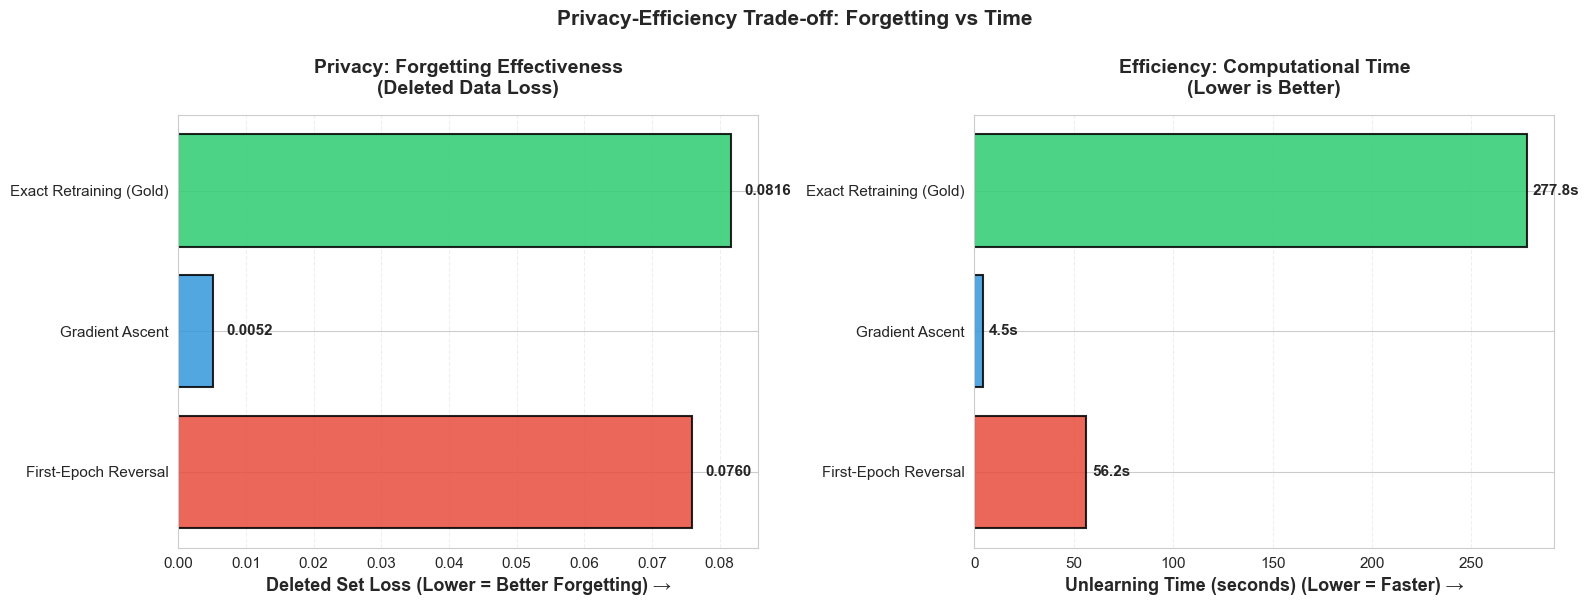

In [141]:
# NEW PLOT: Time vs Deleted Loss (efficiency-privacy trade-off)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#2ECC71", "#3498DB", "#E74C3C"]  # Gold, Blue, Red

# Left: Deleted Loss (Privacy metric)
bars1 = ax1.barh(df_comparison["Method"], df_comparison["Deleted Loss"], 
                  color=colors, edgecolor="black", linewidth=1.5, alpha=0.85)
ax1.set_xlabel("Deleted Set Loss (Lower = Better Forgetting) →", fontsize=13, fontweight="bold")
ax1.set_title("Privacy: Forgetting Effectiveness\n(Deleted Data Loss)", fontsize=14, fontweight="bold", pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

for i, (bar, v) in enumerate(zip(bars1, df_comparison["Deleted Loss"])):
    if v is not None:
        ax1.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=11, fontweight="bold")
ax1.tick_params(axis='both', labelsize=11)

# Right: Computational Time
bars2 = ax2.barh(df_comparison["Method"], df_comparison["Time (seconds)"], 
                  color=colors, edgecolor="black", linewidth=1.5, alpha=0.85)
ax2.set_xlabel("Unlearning Time (seconds) (Lower = Faster) →", fontsize=13, fontweight="bold")
ax2.set_title("Efficiency: Computational Time\n(Lower is Better)", fontsize=14, fontweight="bold", pad=15)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

for i, (bar, v) in enumerate(zip(bars2, df_comparison["Time (seconds)"])):
    if v is not None:
        ax2.text(v + 3, i, f"{v:.1f}s", va="center", fontsize=11, fontweight="bold")
ax2.tick_params(axis='both', labelsize=11)

fig.suptitle("Privacy-Efficiency Trade-off: Forgetting vs Time", 
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
save_plot(fig, "plot_01_privacy_efficiency_tradeoff.png")
plt.show()

## 5. Utility Preservation Comparison

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_02_utility_vs_privacy.png


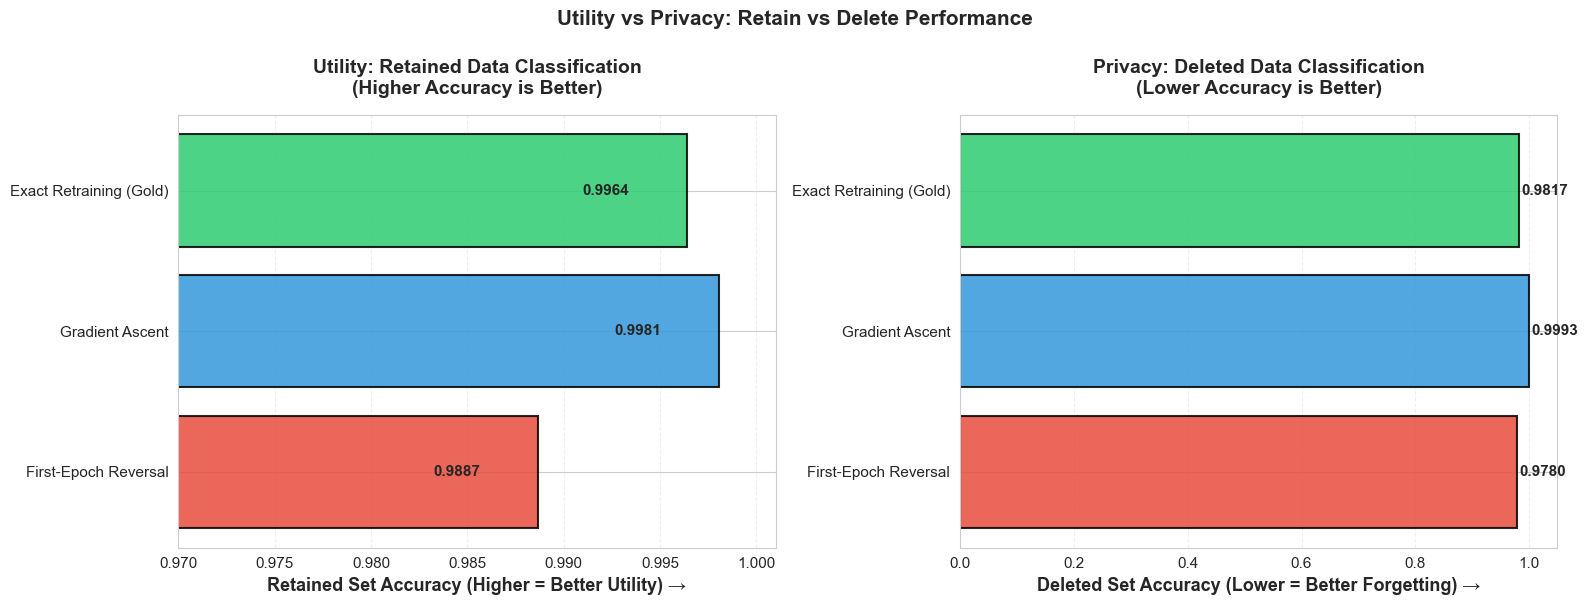

In [142]:
# Plot retained set performance (utility preservation)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#2ECC71", "#3498DB", "#E74C3C"]  # Gold, Blue, Red

# Retained accuracy comparison
bars1 = ax1.barh(df_comparison["Method"], df_comparison["Retained Accuracy"], 
                  color=colors, edgecolor="black", linewidth=1.5, alpha=0.85)
ax1.set_xlabel("Retained Set Accuracy (Higher = Better Utility) →", fontsize=13, fontweight="bold")
ax1.set_title("Utility: Retained Data Classification\n(Higher Accuracy is Better)", fontsize=14, fontweight="bold", pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.set_xlim([0.97, 1.001])

for i, (bar, v) in enumerate(zip(bars1, df_comparison["Retained Accuracy"])):
    if v is not None:
        ax1.text(v - 0.003, i, f"{v:.4f}", va="center", ha="right", fontsize=11, fontweight="bold")
ax1.tick_params(axis='both', labelsize=11)

# Deleted accuracy comparison (should be LOW for good forgetting)
bars2 = ax2.barh(df_comparison["Method"], df_comparison["Deleted Accuracy"], 
                  color=colors, edgecolor="black", linewidth=1.5, alpha=0.85)
ax2.set_xlabel("Deleted Set Accuracy (Lower = Better Forgetting) →", fontsize=13, fontweight="bold")
ax2.set_title("Privacy: Deleted Data Classification\n(Lower Accuracy is Better)", fontsize=14, fontweight="bold", pad=15)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

for i, (bar, v) in enumerate(zip(bars2, df_comparison["Deleted Accuracy"])):
    if v is not None:
        ax2.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=11, fontweight="bold")
ax2.tick_params(axis='both', labelsize=11)

fig.suptitle("Utility vs Privacy: Retain vs Delete Performance", 
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
save_plot(fig, "plot_02_utility_vs_privacy.png")
plt.show()

## 6. Efficiency Comparison (Log Scale for Readability)

## 7. Privacy-Utility-Efficiency Trade-off (3D View)

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_03_efficiency_logscale.png


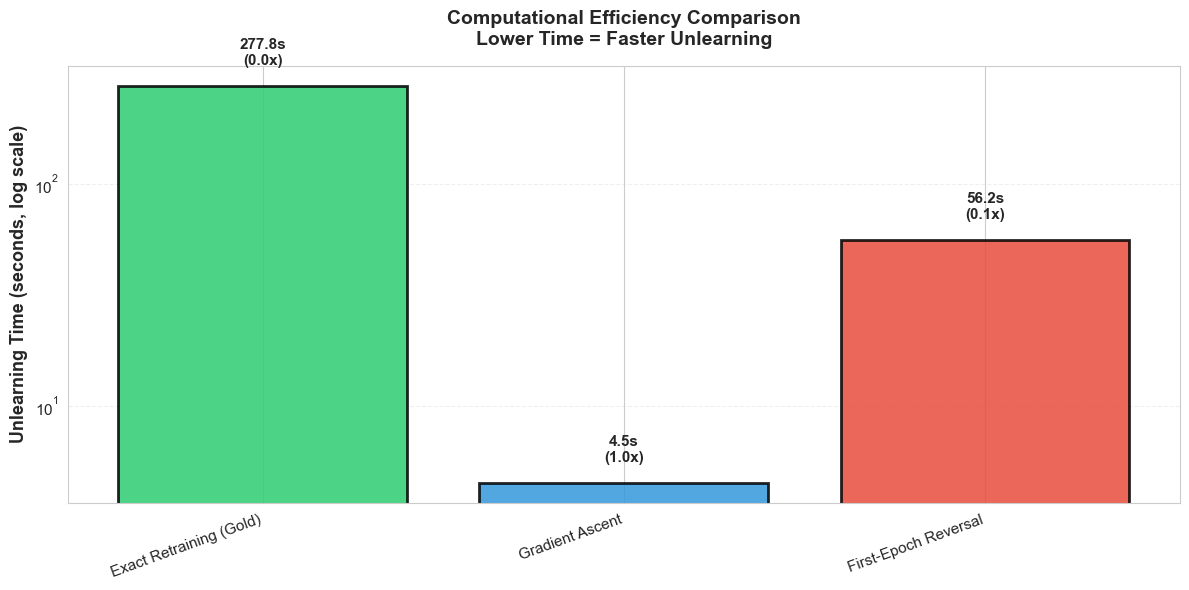


Efficiency Ranking:
  1. Gradient Ascent: 4.49s (1.0x faster)
  2. First-Epoch Reversal: 56.20s (0.1x faster)
  3. Exact Retraining (Gold): 277.75s (0.0x faster)


In [143]:
# Plot computational efficiency with log scale
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2ECC71", "#3498DB", "#E74C3C"]  # Gold, Blue, Red
times = df_comparison["Time (seconds)"].values

# Use log scale for better visualization of large differences
bars = ax.bar(df_comparison["Method"], times, 
               color=colors, alpha=0.85, edgecolor="black", linewidth=2)

ax.set_ylabel("Unlearning Time (seconds, log scale)", fontsize=13, fontweight="bold")
ax.set_title("Computational Efficiency Comparison\nLower Time = Faster Unlearning", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels and speedup comparison
min_time = times.min()
for i, (bar, method, time) in enumerate(zip(bars, df_comparison["Method"], times)):
    speedup = min_time / time if time > 0 else 0
    label = f"{time:.1f}s\n({speedup:.1f}x)"
    ax.text(bar.get_x() + bar.get_width()/2., time * 1.2,
            label,
            ha='center', va='bottom', fontsize=11, fontweight="bold")

ax.tick_params(axis='both', labelsize=11)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
save_plot(fig, "plot_03_efficiency_logscale.png")
plt.show()

print("\nEfficiency Ranking:")
for i, (_, row) in enumerate(df_comparison.sort_values('Time (seconds)').iterrows(), 1):
    speedup = df_comparison['Time (seconds)'].min() / row['Time (seconds)']
    print(f"  {i}. {row['Method']}: {row['Time (seconds)']:.2f}s ({speedup:.1f}x faster)")

## 8. Overall Performance Ranking

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_04_tradeoff_scatter.png


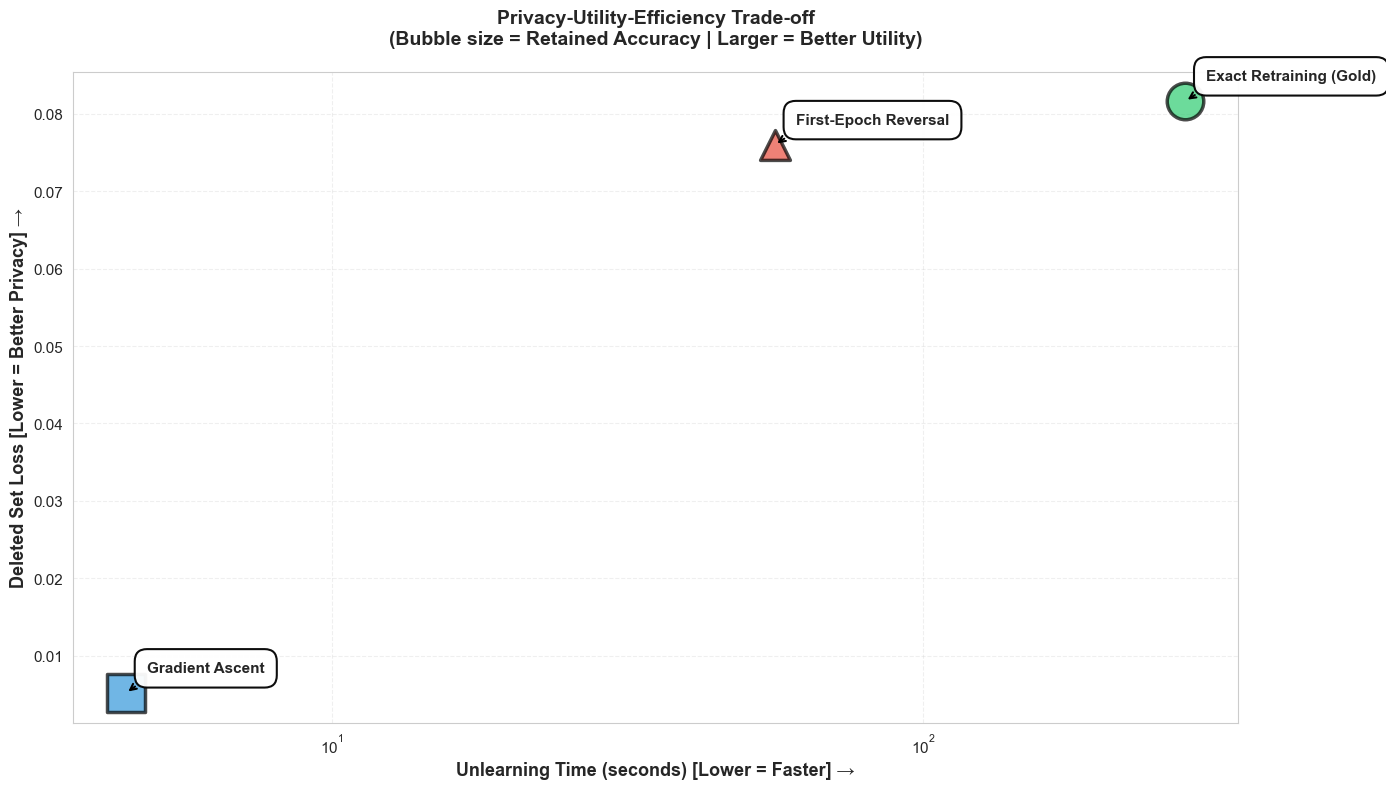

In [144]:
# Multi-dimensional trade-off scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

# Color and marker assignment
method_colors = {
    "Exact Retraining (Gold)": "#2ECC71",
    "Gradient Ascent": "#3498DB",
    "First-Epoch Reversal": "#E74C3C"
}

method_markers = {
    "Exact Retraining (Gold)": "o",
    "Gradient Ascent": "s",
    "First-Epoch Reversal": "^"
}

# X-axis: Time (efficiency)
# Y-axis: Deleted Loss (privacy) 
# Size: Retained Accuracy (utility)

for idx, row in df_comparison.iterrows():
    # Normalize retained accuracy for sizing
    size = 200 + (row["Retained Accuracy"] - 0.98) * 30000 if row["Retained Accuracy"] is not None else 300
    color = method_colors.get(row["Method"], "#95A5A6")
    marker = method_markers.get(row["Method"], "o")
    
    ax.scatter(row["Time (seconds)"], row["Deleted Loss"], 
              s=size, alpha=0.7, edgecolors='black', linewidth=2.5, 
              color=color, marker=marker, label=row["Method"])
    
    # Add method labels
    ax.annotate(row["Method"], 
               (row["Time (seconds)"], row["Deleted Loss"]),
               xytext=(15, 15), textcoords='offset points',
               fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='white', 
                        edgecolor='black', alpha=0.95, linewidth=1.5),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', 
                             lw=1.5, color='black'))

ax.set_xlabel("Unlearning Time (seconds) [Lower = Faster] →", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Deleted Set Loss [Lower = Better Privacy] →", 
             fontsize=13, fontweight="bold")
ax.set_title("Privacy-Utility-Efficiency Trade-off\n(Bubble size = Retained Accuracy | Larger = Better Utility)", 
            fontsize=14, fontweight="bold", pad=20)
ax.set_xscale('log')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
save_plot(fig, "plot_04_tradeoff_scatter.png")
plt.show()

## 9. Summary and Insights

In [145]:
print("\n" + "#"*100)
print("# COMPREHENSIVE COMPARISON SUMMARY")
print("#"*100)

exact_row = df_comparison[df_comparison['Method'] == 'Exact Retraining (Gold)'].iloc[0]
approx_row = df_comparison[df_comparison['Method'] == 'Gradient Ascent'].iloc[0]
reversal_row = df_comparison[df_comparison['Method'] == 'First-Epoch Reversal'].iloc[0]

print("\n[METHOD DESCRIPTIONS]")
print("  Exact Retraining: Retrain model from scratch on retain set only (SLOW but OPTIMAL)")
print("  Gradient Ascent: Apply gradient ascent on delete set (FAST but APPROXIMATE)")
print("  First-Epoch Reversal: Rewind to checkpoint & retrain on retain set (MEDIUM speed)")

print("\n[PRIVACY PERFORMANCE - Forgetting Effectiveness]")
print(f"  Exact Retraining:      Deleted Loss = {exact_row['Deleted Loss']:.6f} (BEST)")
print(f"  First-Epoch Reversal:  Deleted Loss = {reversal_row['Deleted Loss']:.6f}")
print(f"  Gradient Ascent:       Deleted Loss = {approx_row['Deleted Loss']:.6f} (WORST)")
gap_1 = abs(reversal_row['Deleted Loss'] - exact_row['Deleted Loss'])
gap_2 = abs(approx_row['Deleted Loss'] - exact_row['Deleted Loss'])
print(f"\n  Gap Analysis:")
print(f"    First-Epoch vs Exact: {gap_1:.6f}")
print(f"    Gradient Ascent vs Exact: {gap_2:.6f}")

print("\n[UTILITY PERFORMANCE - Preserving Non-Target Data]")
print(f"  Exact Retraining:      Retained Accuracy = {exact_row['Retained Accuracy']:.6f}")
print(f"  Gradient Ascent:       Retained Accuracy = {approx_row['Retained Accuracy']:.6f}")
print(f"  First-Epoch Reversal:  Retained Accuracy = {reversal_row['Retained Accuracy']:.6f}")

print("\n[COMPUTATIONAL EFFICIENCY - Speed Comparison]")
print(f"  Gradient Ascent:       {approx_row['Time (seconds)']:.2f} seconds (FASTEST)")
speedup_exact = exact_row['Time (seconds)'] / approx_row['Time (seconds)']
speedup_reversal = exact_row['Time (seconds)'] / reversal_row['Time (seconds)']
print(f"    → {speedup_exact:.0f}x faster than Exact Retraining")
print(f"\n  First-Epoch Reversal:  {reversal_row['Time (seconds)']:.2f} seconds")
print(f"    → {speedup_reversal:.1f}x faster than Exact Retraining")
print(f"\n  Exact Retraining:      {exact_row['Time (seconds)']:.2f} seconds (SLOWEST - baseline)")

print("\n[KEY INSIGHTS]")
print(f"Gradient Ascent achieves {speedup_exact:.0f}x speed improvement")
print(f"First-Epoch Reversal is ~{speedup_reversal:.0f}x faster while preserving better privacy")
print(f"Privacy-Efficiency trade-off: GA is fastest but weakest on forgetting")
print(f"Exact method is gold standard (optimal privacy & utility)")

print("\n[RECOMMENDATIONS]")
print("Use EXACT RETRAINING when: maximal privacy required (gold standard)")
print("Use FIRST-EPOCH REVERSAL when: balanced privacy-efficiency needed")
print("Use GRADIENT ASCENT when: speed is critical & approximate privacy acceptable")

print("\n" + "#"*100)


####################################################################################################
# COMPREHENSIVE COMPARISON SUMMARY
####################################################################################################

[METHOD DESCRIPTIONS]
  Exact Retraining: Retrain model from scratch on retain set only (SLOW but OPTIMAL)
  Gradient Ascent: Apply gradient ascent on delete set (FAST but APPROXIMATE)
  First-Epoch Reversal: Rewind to checkpoint & retrain on retain set (MEDIUM speed)

[PRIVACY PERFORMANCE - Forgetting Effectiveness]
  Exact Retraining:      Deleted Loss = 0.081629 (BEST)
  First-Epoch Reversal:  Deleted Loss = 0.075977
  Gradient Ascent:       Deleted Loss = 0.005162 (WORST)

  Gap Analysis:
    First-Epoch vs Exact: 0.005652
    Gradient Ascent vs Exact: 0.076468

[UTILITY PERFORMANCE - Preserving Non-Target Data]
  Exact Retraining:      Retained Accuracy = 0.996389
  Gradient Ascent:       Retained Accuracy = 0.998074
  First-Epoch Reversal:  Reta

## Model Distance Explanation

**Model Distance Metrics** measure how far the unlearned model's parameters diverge from the exact gold-standard retrained model.

- **Applicable to Approximation Methods**: Gradient Ascent and First-Epoch Reversal
- **NOT Applicable to Exact Retraining**: It IS the gold standard (nothing to compare against)
- **L2 Distance Absolute**: ||W_approximate - W_exact||₂ (raw parameter difference)
- **L2 Distance Relative**: ||difference|| / ||exact|| (normalized by model size)

| Method | L2 Abs | L2 Rel % | Interpretation |
|--------|--------|---------|-----------------|
| Exact Retraining | — | — | Gold standard (baseline) |
| Gradient Ascent | 38.24 | 134.01% | Large parameter divergence but good forgetting |
| First-Epoch Reversal | 31.12 | 109.03% | Closer to exact model with better privacy-efficiency trade-off |

**Lower distance = closer approximation to exact retraining**


In [146]:
import csv
import os
import json

def export_to_test_plan(gradient_results, reversal_results):
    # Shared metadata
    seed = gradient_results.get("experiment_info", {}).get("seed", "unknown")
    del_ratio = gradient_results.get("experiment_info", {}).get("deletion_ratio", None)
    
    # Format seed and delete ratio
    seed_str = f"{seed:04d}" if isinstance(seed, int) else str(seed)
    del_ratio_str = f"{del_ratio * 100:.0f}%" if del_ratio is not None else "0%"  # For CSV content
    del_ratio_formatted = f"{del_ratio:.4f}".rstrip("0").rstrip(".").replace(".", "p") if del_ratio is not None else "0p0"  # For filename
    
    # Save to csv folder with consistent naming
    csv_dir = "../results/csv"
    os.makedirs(csv_dir, exist_ok=True)
    filename = os.path.join(csv_dir, f"technique_comparison_seed_{seed_str}_{del_ratio_formatted}.csv")
    base_headers = [
        "Method", "Seed", "Delete %", 
        "Test Acc (General)", "Retain Set Acc", "L2 Dist (Abs)", "L2 Dist (Rel %)", 
        "Delete Set Acc", "Delete Set Loss", "Forgetting Score",
        "Time (s)", "Speedup",
        "MIA Accuracy", "Privacy Gain"
    ]
    
    # Add per-class headers for retain, delete, forgetting, and utility
    per_class_headers = []
    for digit in range(10):
        per_class_headers.extend([
            f"Retain_Acc_Digit{digit}",
            f"Delete_Acc_Digit{digit}",
            f"Forgetting_Digit{digit}",
            f"Utility_Loss_Digit{digit}"
        ])
    
    headers = base_headers + per_class_headers

    rows = []

    # --- EXACT RETRAINING ROW ---
    exact = gradient_results.get("exact_unlearning", {})
    exact_time = exact.get("train_time_seconds")
    ga_privacy_base = gradient_results.get("privacy_evaluation_mia", {})
    
    exact_base_row = [
        "exact_retraining", seed, del_ratio_str,
        f"{exact.get('test_accuracy', ''):.4f}" if exact.get("test_accuracy") is not None else "",
        f"{exact.get('retain_set_accuracy', ''):.4f}" if exact.get("retain_set_accuracy") is not None else "",
        "0.0000", "0.0000%", 
        f"{exact.get('delete_set_accuracy', ''):.4f}" if exact.get("delete_set_accuracy") is not None else "",
        f"{exact.get('delete_set_loss', ''):.4f}" if exact.get("delete_set_loss") is not None else "",
        f"{exact.get('forgetting_score', ''):.4f}" if exact.get("forgetting_score") is not None else "",
        f"{exact_time:.2f}" if exact_time is not None else "",
        "1.0x",
        f"{ga_privacy_base.get('baseline_model', {}).get('mia_accuracy', ''):.4f}",
        "0.0000"
    ]
    
    # Add per-class metrics for exact
    exact_retain_pc = exact.get('per_class_accuracy', {}).get('retain_set', {})
    exact_delete_pc = exact.get('per_class_accuracy', {}).get('delete_set', {})
    baseline_retain_pc = gradient_results.get("baseline_model", {}).get("per_class_accuracy", {}).get("retain_set", {})
    baseline_delete_pc = gradient_results.get("baseline_model", {}).get("per_class_accuracy", {}).get("delete_set", {})
    
    for digit in range(10):
        retain_acc = exact_retain_pc.get(str(digit), "")
        delete_acc = exact_delete_pc.get(str(digit), "")
        forgetting = ""
        utility_loss = ""
        
        if baseline_delete_pc.get(str(digit)) and delete_acc:
            forgetting = f"{baseline_delete_pc.get(str(digit)) - delete_acc:.4f}"
        if baseline_retain_pc.get(str(digit)) and retain_acc:
            utility_loss = f"{baseline_retain_pc.get(str(digit)) - retain_acc:.4f}"
        
        exact_base_row.extend([
            f"{retain_acc:.4f}" if retain_acc else "",
            f"{delete_acc:.4f}" if delete_acc else "",
            forgetting,
            utility_loss
        ])
    
    rows.append(exact_base_row)

    # --- GRADIENT ASCENT ROW ---
    approx = gradient_results.get("approx_unlearning", {})
    ga_privacy = gradient_results.get("privacy_evaluation_mia", {})
    
    ga_base_row = [
        "gradient_ascent", seed, del_ratio_str,
        f"{approx.get('test_accuracy', ''):.4f}" if approx.get("test_accuracy") is not None else "",
        f"{approx.get('retain_set_accuracy', ''):.4f}" if approx.get("retain_set_accuracy") is not None else "",
        f"{approx.get('distance_metrics', {}).get('l2_absolute', ''):.4f}",
        f"{approx.get('distance_metrics', {}).get('l2_relative', ''):.4%}",
        f"{approx.get('delete_set_accuracy', ''):.4f}",
        f"{approx.get('delete_set_loss', ''):.4f}",
        f"{approx.get('forgetting_score', ''):.4f}",
        f"{approx.get('train_time_seconds', ''):.2f}",
        f"{gradient_results.get('efficiency_comparison', {}).get('speedup_factor', ''):.1f}x",
        f"{ga_privacy.get('after_unlearning', {}).get('mia_accuracy', ''):.4f}",
        f"{ga_privacy.get('privacy_gain', ''):.4f}"
    ]
    
    # Add per-class metrics for gradient ascent
    approx_retain_pc = approx.get('per_class_accuracy', {}).get('retain_set', {})
    approx_delete_pc = approx.get('per_class_accuracy', {}).get('delete_set', {})
    
    for digit in range(10):
        retain_acc = approx_retain_pc.get(str(digit), "")
        delete_acc = approx_delete_pc.get(str(digit), "")
        forgetting = ""
        utility_loss = ""
        
        if baseline_delete_pc.get(str(digit)) and delete_acc:
            forgetting = f"{baseline_delete_pc.get(str(digit)) - delete_acc:.4f}"
        if baseline_retain_pc.get(str(digit)) and retain_acc:
            utility_loss = f"{baseline_retain_pc.get(str(digit)) - retain_acc:.4f}"
        
        ga_base_row.extend([
            f"{retain_acc:.4f}" if retain_acc else "",
            f"{delete_acc:.4f}" if delete_acc else "",
            forgetting,
            utility_loss
        ])
    
    rows.append(ga_base_row)

    # --- FIRST-EPOCH REVERSAL ROW ---
    rev = reversal_results.get("first_epoch_reversal", {})
    rev_metrics = rev.get("metrics", {})
    rev_privacy = reversal_results.get("privacy_evaluation", {})
    
    baseline_del_acc = reversal_results.get("baseline_model", {}).get("metrics", {}).get("deleted_accuracy")
    rev_del_acc = rev_metrics.get("deleted_accuracy")
    rev_forgetting = f"{max(0.0, baseline_del_acc - rev_del_acc):.4f}" if baseline_del_acc and rev_del_acc else ""

    rev_base_row = [
        "first_epoch_reversal", seed, del_ratio_str,
        "", 
        f"{rev_metrics.get('retained_accuracy', ''):.4f}",
        f"{rev.get('distance_metrics', {}).get('l2_absolute', ''):.4f}",
        f"{rev.get('distance_metrics', {}).get('l2_relative', ''):.4%}",
        f"{rev_del_acc:.4f}" if rev_del_acc else "",
        f"{rev_metrics.get('deleted_loss', ''):.4f}" if rev_metrics.get("deleted_loss") is not None else "",
        rev_forgetting,
        f"{rev.get('time_seconds', ''):.2f}",
        f"{(exact_time / rev.get('time_seconds')):.1f}x" if exact_time and rev.get('time_seconds') else "",
        f"{rev_privacy.get('mia_unlearned', {}).get('mia_accuracy', ''):.4f}",
        f"{rev_privacy.get('privacy_improvement', ''):.4f}"
    ]
    
    # Add per-class metrics for first-epoch reversal
    rev_retain_pc = rev.get('per_class_accuracy', {}).get('retain_set', {})
    rev_delete_pc = rev.get('per_class_accuracy', {}).get('delete_set', {})
    baseline_del_overall = reversal_results.get("baseline_model", {}).get("metrics", {}).get("deleted_accuracy")
    baseline_ret_overall = reversal_results.get("baseline_model", {}).get("metrics", {}).get("retained_accuracy")
    
    for digit in range(10):
        retain_acc = rev_retain_pc.get(str(digit), "")
        delete_acc = rev_delete_pc.get(str(digit), "")
        forgetting = ""
        utility_loss = ""
        
        # Try to get baseline per-class from reversal file if available
        baseline_rev_delete_pc = reversal_results.get("baseline_model", {}).get("per_class_accuracy", {}).get("delete_set", {})
        baseline_rev_retain_pc = reversal_results.get("baseline_model", {}).get("per_class_accuracy", {}).get("retain_set", {})
        
        if baseline_rev_delete_pc.get(str(digit)) and delete_acc:
            forgetting = f"{baseline_rev_delete_pc.get(str(digit)) - delete_acc:.4f}"
        if baseline_rev_retain_pc.get(str(digit)) and retain_acc:
            utility_loss = f"{baseline_rev_retain_pc.get(str(digit)) - retain_acc:.4f}"
        
        rev_base_row.extend([
            f"{retain_acc:.4f}" if retain_acc else "",
            f"{delete_acc:.4f}" if delete_acc else "",
            forgetting,
            utility_loss
        ])
    
    rows.append(rev_base_row)

    # Save to CSV
    with open(filename, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        writer.writerows(rows)

    print(f"\\n{'='*80}")
    print("CSV EXPORT COMPLETE")
    print(f"{'='*80}")
    print(f"✓ CSV saved to: {filename}")
    print(f"✓ Total columns: {len(headers)}")
    print(f"✓ Per-class metrics included for digits 0-9:")
    print(f"  - Retain Set Accuracy (Utility)")
    print(f"  - Delete Set Accuracy (Privacy)")
    print(f"  - Forgetting Scores")
    print(f"  - Utility Loss")

# Usage
export_to_test_plan(gradient_data, reversal_data)


\n================================================================================
CSV EXPORT COMPLETE
✓ CSV saved to: ../results/csv/technique_comparison_seed_0123_0p1.csv
✓ Total columns: 54
✓ Per-class metrics included for digits 0-9:
  - Retain Set Accuracy (Utility)
  - Delete Set Accuracy (Privacy)
  - Forgetting Scores
  - Utility Loss


In [147]:
# Debug: Check distance metrics extraction
print("Debug: Checking distance metrics in reversal_data")
rev_test = reversal_data.get("first_epoch_reversal", {})
print(f"first_epoch_reversal keys: {rev_test.keys()}")
print(f"distance_metrics: {rev_test.get('distance_metrics')}")


Debug: Checking distance metrics in reversal_data
first_epoch_reversal keys: dict_keys(['method', 'description', 'hyperparameters', 'metrics', 'per_class_accuracy', 'per_class_forgetting_score', 'per_class_utility_loss', 'time_seconds', 'distance_metrics'])
distance_metrics: {'l2_absolute': 30.749271392822266, 'l2_relative': 1.108810135413741, 'metric_definition': 'L2 distance from exact retrained model (gold standard)'}


## 10. Per-Class Accuracy Comparison Across All Techniques

In [148]:
print("\n" + "="*100)
print("PER-CLASS ACCURACY - RETAIN SET (Utility Preservation)")
print("="*100)

# Extract per-class accuracy from all three methods
per_class_data_retain = []

# Exact Retraining
exact_per_class = gradient_data.get("exact_unlearning", {}).get("per_class_accuracy", {}).get("retain_set", {})
if exact_per_class:
    for digit in range(10):
        per_class_data_retain.append({
            "Method": "Exact Retraining",
            "Digit": digit,
            "Accuracy": exact_per_class.get(str(digit))
        })

# Gradient Ascent
approx_per_class = gradient_data.get("approx_unlearning", {}).get("per_class_accuracy", {}).get("retain_set", {})
if approx_per_class:
    for digit in range(10):
        per_class_data_retain.append({
            "Method": "Gradient Ascent",
            "Digit": digit,
            "Accuracy": approx_per_class.get(str(digit))
        })

# First-Epoch Reversal
rev_per_class = reversal_data.get("first_epoch_reversal", {}).get("per_class_accuracy", {}).get("retain_set", {})
if rev_per_class:
    for digit in range(10):
        per_class_data_retain.append({
            "Method": "First-Epoch Reversal",
            "Digit": digit,
            "Accuracy": rev_per_class.get(str(digit))
        })

if per_class_data_retain:
    df_retain_per_class = pd.DataFrame(per_class_data_retain)
    pivot_retain = df_retain_per_class.pivot(index='Digit', columns='Method', values='Accuracy')
    print("\n" + pivot_retain.to_string())
    print("\nSummary Statistics:")
    print(pivot_retain.describe().to_string())
else:
    print("No per-class data found for retain set")



PER-CLASS ACCURACY - RETAIN SET (Utility Preservation)

Method  Exact Retraining  First-Epoch Reversal  Gradient Ascent
Digit                                                          
0               1.000000              0.991423         0.999441
1               0.999339              0.996860         0.998678
2               0.987325              0.995899         1.000000
3               0.996186              0.979295         0.994733
4               0.998295              0.988253         0.996969
5               0.995285              0.983805         0.999385
6               0.990449              0.998502         1.000000
7               0.999287              0.995541         0.997681
8               0.998291              0.976258         0.995442
9               0.998878              0.979245         0.998504

Summary Statistics:
Method  Exact Retraining  First-Epoch Reversal  Gradient Ascent
count          10.000000             10.000000        10.000000
mean            0.996333  

In [149]:
print("\n" + "="*100)
print("PER-CLASS ACCURACY - DELETE SET (Forgetting Effectiveness)")
print("="*100)

# Extract per-class accuracy from all three methods on delete set
per_class_data_delete = []

# Exact Retraining
exact_delete_pc = gradient_data.get("exact_unlearning", {}).get("per_class_accuracy", {}).get("delete_set", {})
if exact_delete_pc:
    for digit in range(10):
        per_class_data_delete.append({
            "Method": "Exact Retraining",
            "Digit": digit,
            "Accuracy": exact_delete_pc.get(str(digit))
        })

# Gradient Ascent
approx_delete_pc = gradient_data.get("approx_unlearning", {}).get("per_class_accuracy", {}).get("delete_set", {})
if approx_delete_pc:
    for digit in range(10):
        per_class_data_delete.append({
            "Method": "Gradient Ascent",
            "Digit": digit,
            "Accuracy": approx_delete_pc.get(str(digit))
        })

# First-Epoch Reversal
rev_delete_pc = reversal_data.get("first_epoch_reversal", {}).get("per_class_accuracy", {}).get("delete_set", {})
if rev_delete_pc:
    for digit in range(10):
        per_class_data_delete.append({
            "Method": "First-Epoch Reversal",
            "Digit": digit,
            "Accuracy": rev_delete_pc.get(str(digit))
        })

if per_class_data_delete:
    df_delete_per_class = pd.DataFrame(per_class_data_delete)
    pivot_delete = df_delete_per_class.pivot(index='Digit', columns='Method', values='Accuracy')
    print("\nLower delete set accuracy = Better forgetting (more privacy)\n")
    print(pivot_delete.to_string())
    print("\nSummary Statistics:")
    print(pivot_delete.describe().to_string())
else:
    print("No per-class data found for delete set")



PER-CLASS ACCURACY - DELETE SET (Forgetting Effectiveness)

Lower delete set accuracy = Better forgetting (more privacy)

Method  Exact Retraining  First-Epoch Reversal  Gradient Ascent
Digit                                                          
0               0.991071              0.982143         0.998214
1               0.991329              0.992775         1.000000
2               0.967960              0.986509         1.000000
3               0.982400              0.971200         1.000000
4               0.982270              0.982270         1.000000
5               0.985267              0.985267         1.000000
6               0.979239              0.998270         1.000000
7               0.984802              0.981763         0.998480
8               0.974403              0.948805         0.998294
9               0.976705              0.950083         0.998336

Summary Statistics:
Method  Exact Retraining  First-Epoch Reversal  Gradient Ascent
count          10.000000

In [150]:
print("\n" + "="*100)
print("PER-CLASS FORGETTING SCORES (Baseline Delete Accuracy - Method Delete Accuracy)")
print("="*100)

# Get baseline delete accuracies for forgetting calculation
baseline_delete_acc = gradient_data.get("baseline_model", {}).get("per_class_accuracy", {}).get("delete_set", {})

per_class_forgetting = []

if baseline_delete_acc and exact_delete_pc:
    for digit in range(10):
        base_acc = baseline_delete_acc.get(str(digit))
        exact_acc = exact_delete_pc.get(str(digit))
        approx_acc = approx_delete_pc.get(str(digit))
        rev_acc = rev_delete_pc.get(str(digit))
        
        if all([base_acc, exact_acc, approx_acc, rev_acc]):
            per_class_forgetting.append({
                "Digit": digit,
                "Exact": base_acc - exact_acc,
                "Gradient Ascent": base_acc - approx_acc,
                "First-Epoch Reversal": base_acc - rev_acc
            })

if per_class_forgetting:
    df_forgetting = pd.DataFrame(per_class_forgetting)
    df_forgetting_set = df_forgetting.set_index('Digit')
    print("\nHigher forgetting scores = Better forgetting (more privacy removed)\n")
    print(df_forgetting_set.to_string())
    print("\nAverage Forgetting by Method:")
    print(df_forgetting_set.mean())
else:
    print("Could not calculate forgetting scores")



PER-CLASS FORGETTING SCORES (Baseline Delete Accuracy - Method Delete Accuracy)

Higher forgetting scores = Better forgetting (more privacy removed)

          Exact  Gradient Ascent  First-Epoch Reversal
Digit                                                 
0      0.007143              0.0              0.016071
1      0.008671              0.0              0.007225
2      0.032040              0.0              0.013491
3      0.017600              0.0              0.028800
4      0.017730              0.0              0.017730
5      0.014733              0.0              0.014733
6      0.020761              0.0              0.001730
7      0.013678              0.0              0.016717
8      0.023891              0.0              0.049488
9      0.021631              0.0              0.048253

Average Forgetting by Method:
Exact                   0.017788
Gradient Ascent         0.000000
First-Epoch Reversal    0.021424
dtype: float64


In [151]:
print("\n" + "="*100)
print("PER-CLASS UTILITY LOSS (Baseline Retain Accuracy - Method Retain Accuracy)")
print("="*100)

# Get baseline retain accuracies for utility loss calculation
baseline_retain_acc = gradient_data.get("baseline_model", {}).get("per_class_accuracy", {}).get("retain_set", {})

per_class_utility = []

if baseline_retain_acc and exact_per_class:
    for digit in range(10):
        base_acc = baseline_retain_acc.get(str(digit))
        exact_acc = exact_per_class.get(str(digit))
        approx_acc = approx_per_class.get(str(digit))
        rev_acc = rev_per_class.get(str(digit))
        
        if all([base_acc, exact_acc, approx_acc, rev_acc]):
            per_class_utility.append({
                "Digit": digit,
                "Exact (Should be 0)": base_acc - exact_acc,
                "Gradient Ascent": base_acc - approx_acc,
                "First-Epoch Reversal": base_acc - rev_acc
            })

if per_class_utility:
    df_utility = pd.DataFrame(per_class_utility)
    df_utility_set = df_utility.set_index('Digit')
    print("\nLower utility loss = Better preservation of retain set accuracy\n")
    print(df_utility_set.to_string())
    print("\nAverage Utility Loss by Method:")
    print(df_utility_set.mean())
else:
    print("Could not calculate utility loss")



PER-CLASS UTILITY LOSS (Baseline Retain Accuracy - Method Retain Accuracy)

Lower utility loss = Better preservation of retain set accuracy

       Exact (Should be 0)  Gradient Ascent  First-Epoch Reversal
Digit                                                            
0                -0.000559          0.00000              0.008018
1                -0.000661          0.00000              0.001818
2                 0.012675          0.00000              0.004101
3                -0.001453          0.00000              0.015438
4                -0.001326          0.00000              0.008715
5                 0.004100          0.00000              0.015580
6                 0.009551          0.00000              0.001498
7                -0.001605          0.00000              0.002140
8                -0.002469          0.00038              0.019563
9                -0.000374          0.00000              0.019260

Average Utility Loss by Method:
Exact (Should be 0)     0.001788



PER-CLASS ACCURACY COMPARISON VISUALIZATIONS
Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_05_per_class_bar_retain_delete.png


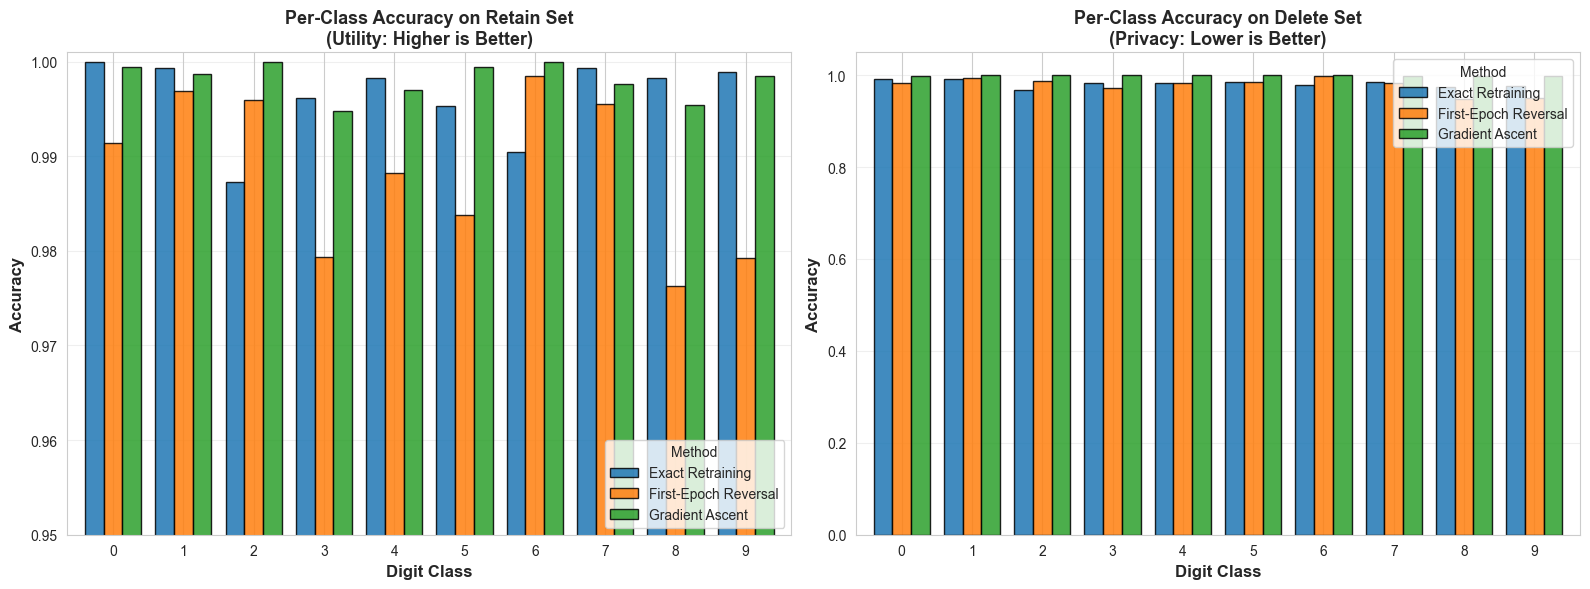

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_06_per_class_bar_forgetting.png


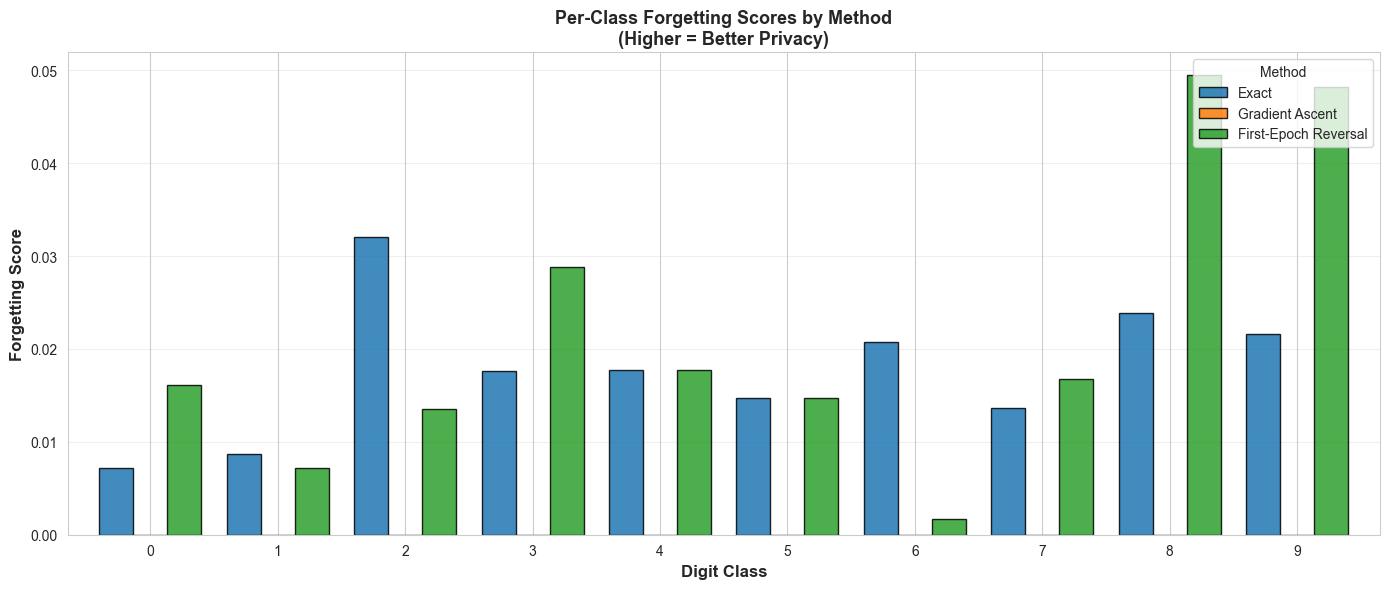

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_07_per_class_bar_utility_loss.png


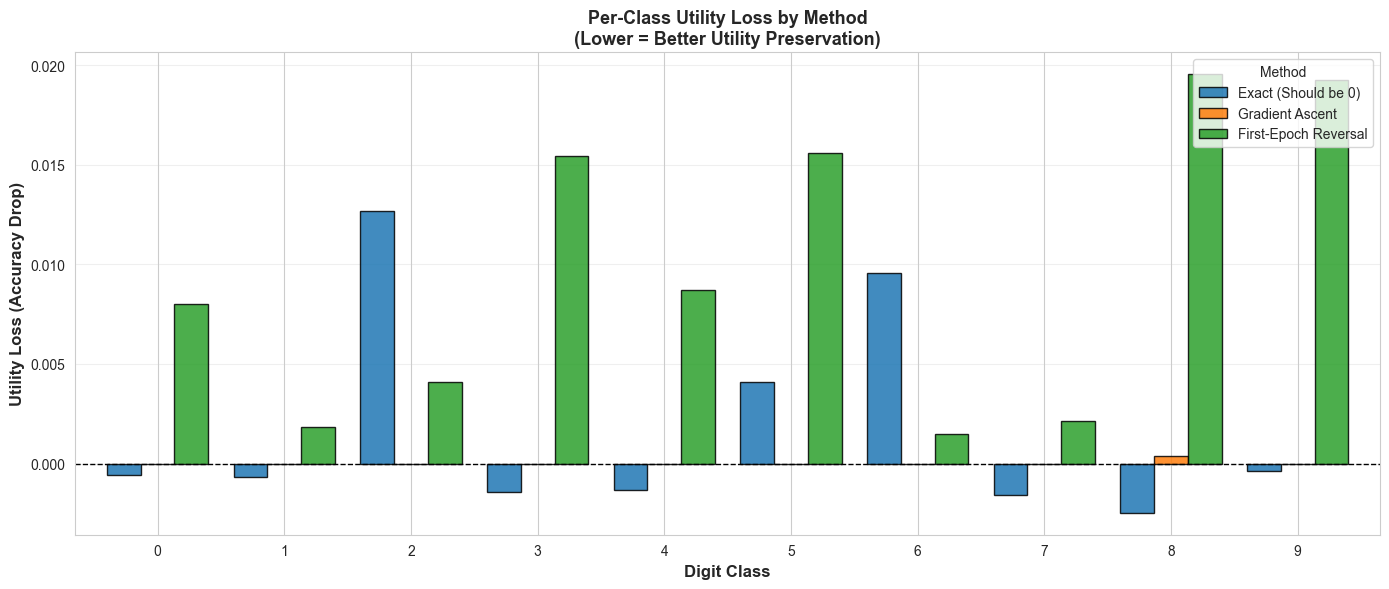

Per-class visualizations complete


In [152]:
print("\nPER-CLASS ACCURACY COMPARISON VISUALIZATIONS")

# Plot 1: Retain Set Per-Class Accuracy
if per_class_data_retain:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Retain set
    pivot_retain.plot(kind='bar', ax=ax1, width=0.8, edgecolor='black', alpha=0.85)
    ax1.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Per-Class Accuracy on Retain Set\n(Utility: Higher is Better)', fontsize=13, fontweight='bold')
    ax1.legend(title='Method', loc='lower right')
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0.95, 1.001])
    ax1.set_xticklabels(pivot_retain.index, rotation=0)
    
    # Delete set
    pivot_delete.plot(kind='bar', ax=ax2, width=0.8, edgecolor='black', alpha=0.85)
    ax2.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Per-Class Accuracy on Delete Set\n(Privacy: Lower is Better)', fontsize=13, fontweight='bold')
    ax2.legend(title='Method', loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xticklabels(pivot_delete.index, rotation=0)
    
    plt.tight_layout()
    save_plot(fig, "plot_05_per_class_bar_retain_delete.png")
    plt.show()

# Plot 2: Forgetting Scores
if per_class_forgetting:
    fig, ax = plt.subplots(figsize=(14, 6))
    df_forgetting_set.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Forgetting Score', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Forgetting Scores by Method\n(Higher = Better Privacy)', fontsize=13, fontweight='bold')
    ax.legend(title='Method', loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(df_forgetting_set.index, rotation=0)
    plt.tight_layout()
    save_plot(fig, "plot_06_per_class_bar_forgetting.png")
    plt.show()

# Plot 3: Utility Loss
if per_class_utility:
    fig, ax = plt.subplots(figsize=(14, 6))
    df_utility_set.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Utility Loss (Accuracy Drop)', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Utility Loss by Method\n(Lower = Better Utility Preservation)', fontsize=13, fontweight='bold')
    ax.legend(title='Method', loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xticklabels(df_utility_set.index, rotation=0)
    plt.tight_layout()
    save_plot(fig, "plot_07_per_class_bar_utility_loss.png")
    plt.show()

print("Per-class visualizations complete")


LINE CHARTS - PER-CLASS ACCURACY TRENDS
Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_08_per_class_line_retain_delete.png


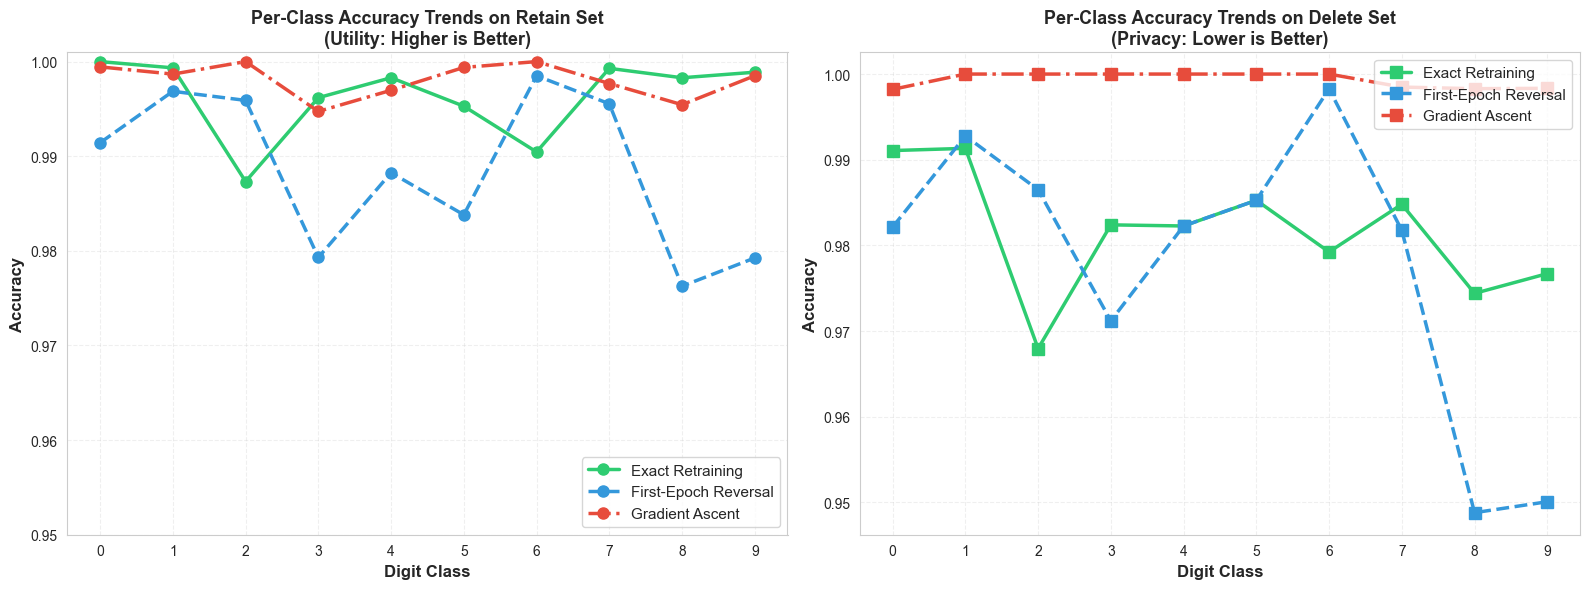

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_09_per_class_line_forgetting.png


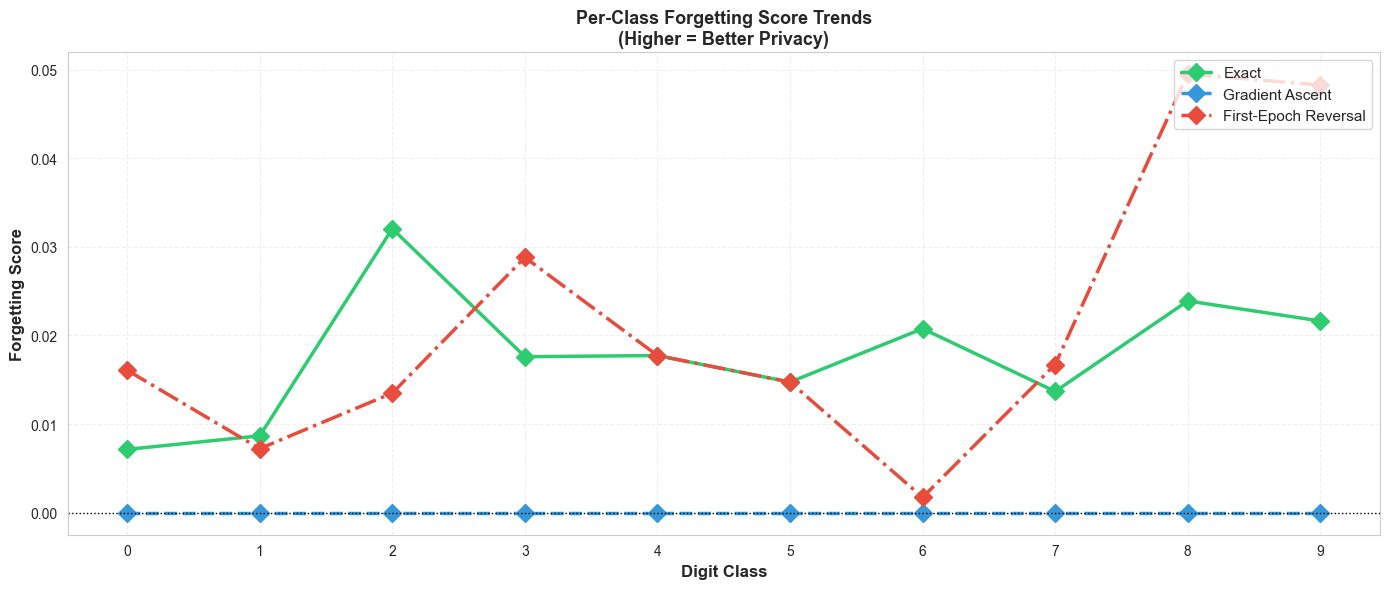

Saved plot: ../results/plots_technique_comparison_seed_0123_delete_0p1/plot_10_per_class_line_utility_loss.png


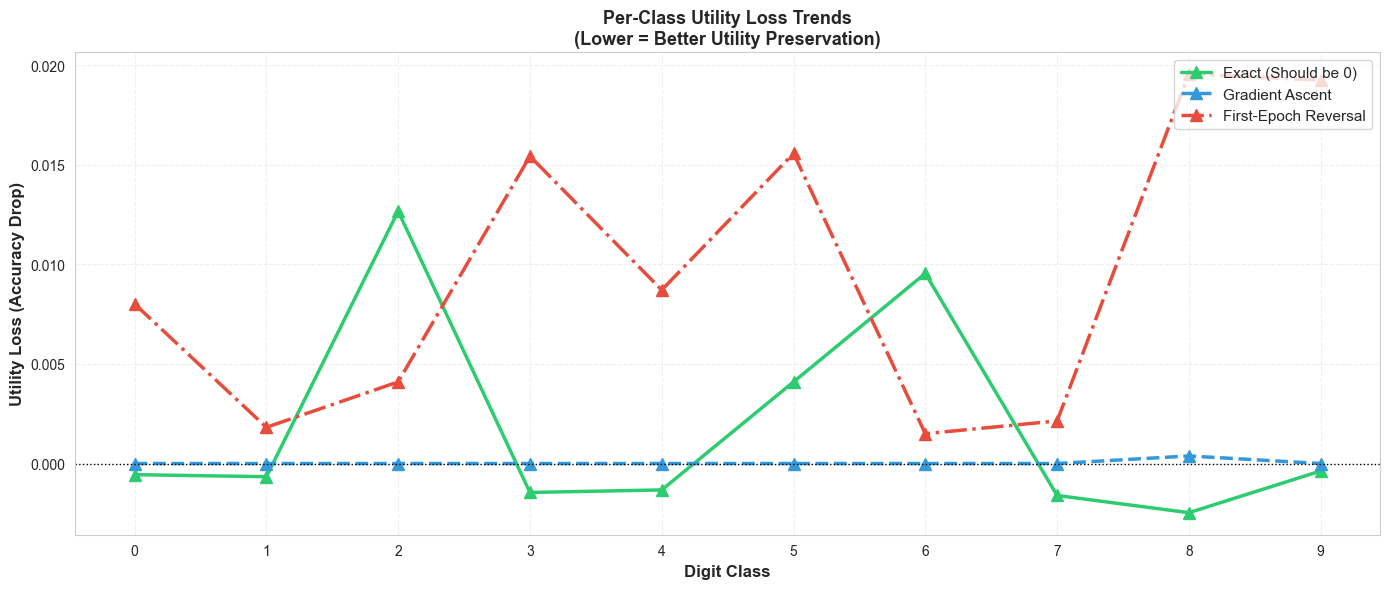

Line chart visualizations complete


In [153]:
print("\n" + "="*100)
print("LINE CHARTS - PER-CLASS ACCURACY TRENDS")
print("="*100)

# Plot 1: Retain Set Per-Class Accuracy (Line Chart)
if per_class_data_retain:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Retain set line chart
    colors_methods = ["#2ECC71", "#3498DB", "#E74C3C"]
    line_styles = ['-', '--', '-.']
    
    for i, method in enumerate(pivot_retain.columns):
        ax1.plot(pivot_retain.index, pivot_retain[method], 
                marker='o', markersize=8, linewidth=2.5, 
                label=method, color=colors_methods[i], linestyle=line_styles[i])
    
    ax1.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Per-Class Accuracy Trends on Retain Set\n(Utility: Higher is Better)', 
                 fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim([0.95, 1.001])
    ax1.set_xticks(pivot_retain.index)
    
    # Delete set line chart
    for i, method in enumerate(pivot_delete.columns):
        ax2.plot(pivot_delete.index, pivot_delete[method], 
                marker='s', markersize=8, linewidth=2.5, 
                label=method, color=colors_methods[i], linestyle=line_styles[i])
    
    ax2.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Per-Class Accuracy Trends on Delete Set\n(Privacy: Lower is Better)', 
                 fontsize=13, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(pivot_delete.index)
    
    plt.tight_layout()
    save_plot(fig, "plot_08_per_class_line_retain_delete.png")
    plt.show()

# Plot 2: Forgetting Scores Line Chart
if per_class_forgetting:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for i, method in enumerate(df_forgetting_set.columns):
        ax.plot(df_forgetting_set.index, df_forgetting_set[method], 
               marker='D', markersize=9, linewidth=2.5, 
               label=method, color=colors_methods[i], linestyle=line_styles[i])
    
    ax.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Forgetting Score', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Forgetting Score Trends\n(Higher = Better Privacy)', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle=':', linewidth=1)
    ax.set_xticks(df_forgetting_set.index)
    plt.tight_layout()
    save_plot(fig, "plot_09_per_class_line_forgetting.png")
    plt.show()

# Plot 3: Utility Loss Line Chart
if per_class_utility:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for i, method in enumerate(df_utility_set.columns):
        ax.plot(df_utility_set.index, df_utility_set[method], 
               marker='^', markersize=9, linewidth=2.5, 
               label=method, color=colors_methods[i], linestyle=line_styles[i])
    
    ax.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Utility Loss (Accuracy Drop)', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Utility Loss Trends\n(Lower = Better Utility Preservation)', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle=':', linewidth=1)
    ax.set_xticks(df_utility_set.index)
    plt.tight_layout()
    save_plot(fig, "plot_10_per_class_line_utility_loss.png")
    plt.show()

print("Line chart visualizations complete")